In [130]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
import lightgbm as lgb
import xgboost as xgb

from sklearn.metrics import recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix

In [131]:
df = pd.read_csv("../data/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [132]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=42, stratify=y)



In [133]:
scaler_amount = StandardScaler()

X_train["Amount_scaled"] = scaler_amount.fit_transform(X_train[["Amount"]])
X_test["Amount_scaled"] = scaler_amount.transform(X_test[["Amount"]])

X_train['Hour'] = (X_train['Time'] / 3600) % 24
X_test['Hour'] = (X_test['Time'] / 3600) % 24

X_train.drop(["Time", "Amount"], axis=1, inplace=True)
X_test.drop(["Time", "Amount"], axis=1, inplace=True)

In [134]:
X_train


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_scaled,Hour
265518,1.946747,-0.752526,-1.355130,-0.661630,1.502822,4.024933,-1.479661,1.139880,1.406819,-0.157403,-0.113729,0.510277,0.061258,-0.066555,1.328702,0.352514,-0.765670,0.141938,-0.451365,-0.134435,0.076197,0.297537,0.307915,0.690980,-0.350316,-0.388907,0.077641,-0.032248,-0.322494,20.977500
180305,2.035149,-0.048880,-3.058693,0.247945,2.943487,3.298697,-0.002192,0.674782,0.045826,0.284864,-0.254903,0.325560,-0.405327,0.721068,-0.148445,-0.754029,-0.270842,-0.695698,-0.274411,-0.227279,0.038628,0.228197,0.035542,0.707090,0.512885,-0.471198,0.002520,-0.069002,-0.339764,10.576944
42664,-0.991920,0.603193,0.711976,-0.992425,-0.825838,1.956261,-2.212603,-5.037523,0.000772,-2.009561,-0.386845,1.820161,0.747777,0.122746,-1.723285,1.123344,-0.724616,0.147255,0.004631,1.280856,-2.798352,0.109526,-0.436530,-0.932803,0.826684,0.913773,0.038049,0.185340,0.346693,11.441944
198723,2.285718,-1.500239,-0.747565,-1.668119,-1.394143,-0.350339,-1.427984,0.010010,-1.118447,1.756121,0.093136,-0.722450,-0.468757,-0.195288,-0.638683,-0.065888,0.072781,0.768237,0.257424,-0.490642,-0.139670,0.077013,0.208310,-0.538236,-0.278032,-0.162068,0.018045,-0.063005,-0.327360,12.840000
82325,-0.448747,-1.011440,0.115903,-3.454854,0.715771,-0.147490,0.504347,-0.113817,-0.044782,-0.558955,-0.251076,-0.054708,-0.782698,0.134659,-0.483007,-2.096099,-0.399525,1.597589,-0.082746,-0.275297,-0.243245,-0.173298,-0.006692,-1.362383,-0.292234,-0.144622,-0.032580,-0.064194,-0.008281,16.488611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233802,1.993864,-0.516866,-0.620118,0.129845,-0.285128,0.395044,-0.822358,0.231591,0.995898,0.212619,0.319897,0.584204,-0.251486,0.062302,0.013795,0.684356,-0.906442,0.739436,0.043943,-0.174051,0.262526,0.884510,0.099141,0.275689,-0.195404,0.623598,-0.032455,-0.058552,-0.327798,17.030556
85418,-1.497933,0.657921,1.581568,-0.024286,0.584698,1.303031,0.609212,0.135561,0.452745,0.108640,0.521818,0.373473,-0.533295,-0.401809,0.771781,-1.879937,1.241541,-2.623211,-1.241768,-0.225079,-0.072452,0.299172,0.110048,-0.615980,-0.425883,0.263968,-0.448445,0.045178,-0.204156,16.878889
29062,1.069777,0.072105,0.496540,1.505318,-0.380277,-0.370243,0.100551,-0.026687,0.319684,-0.131553,-0.305690,0.445453,-0.547450,0.166727,-0.073930,-0.796913,0.404795,-1.033061,-0.500426,-0.149402,-0.061991,-0.044629,-0.050485,0.400171,0.593314,-0.335160,0.031014,0.024886,-0.170533,9.805833
13766,1.280465,0.300586,0.333044,0.512720,0.065052,-0.145844,-0.145519,-0.091833,1.111187,-0.268878,1.708922,-1.666023,2.119731,1.799882,-0.357245,0.705997,-0.247970,0.483059,0.278512,-0.093783,-0.409934,-0.961351,0.033153,-0.560429,0.278428,0.089546,-0.059835,-0.005887,-0.348140,6.781389


In [135]:
print(X_train.shape, X_test.shape)

print(y_train.value_counts())

print(X_train.isnull().sum().sum())  

(227845, 30) (56962, 30)
Class
0    227451
1       394
Name: count, dtype: int64
0


In [136]:
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, baseline_model.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Recall: 0.6530612244897959
Precision: 0.8311688311688312
F1 Score: 0.7314285714285714
ROC AUC Score: 0.9535881530439976
Confusion Matrix:
 [[56851    13]
 [   34    64]]


In [138]:
X_train_smote, y_train_smote = SMOTE(random_state=42).fit_resample(X_train, y_train)
print("counts of labels: " + str(y_train_smote.value_counts()))

counts of labels: Class
0    227451
1    227451
Name: count, dtype: int64


In [ ]:
lr_smote = LogisticRegression(max_iter=1000, random_state=42)
lr_smote.fit(X_train_smote, y_train_smote)

y_pred = lr_smote.predict(X_test)

print("Recall:", recall_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, lr_smote.predict_proba(X_test)[:, 1]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Recall: 0.9081632653061225
Precision: 0.054037644201578625
F1 Score: 0.10200573065902578
ROC AUC Score: 0.971842502124654
Confusion Matrix:
 [[55306  1558]
 [    9    89]]


In [140]:
lgb_model = lgb.LGBMClassifier(random_state=42, class_weight='balanced')
lgb_model.fit(X_train, y_train)

y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM - Recall:", recall_score(y_test, y_pred_lgb))
print("LightGBM - Precision:", precision_score(y_test, y_pred_lgb))
print("LightGBM - F1 Score:", f1_score(y_test, y_pred_lgb))
print("LightGBM - ROC AUC Score:", roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1]))
print("LightGBM - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 394, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.040008 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 227845, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
LightGBM - Recall: 0.8367346938775511
LightGBM - Precision: 0.8118811881188119
LightGBM - F1 Score: 0.8241206030150754
LightGBM - ROC AUC Score: 0.9641884539409462
LightGBM - Confusion Matrix:
 [[56845    19]
 [   16    82]]


In [141]:
lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_model.fit(X_train_smote, y_train_smote)

y_pred_lgb = lgb_model.predict(X_test)

print("LightGBM - Recall:", recall_score(y_test, y_pred_lgb))
print("LightGBM - Precision:", precision_score(y_test, y_pred_lgb))
print("LightGBM - F1 Score:", f1_score(y_test, y_pred_lgb))
print("LightGBM - ROC AUC Score:", roc_auc_score(y_test, lgb_model.predict_proba(X_test)[:, 1]))
print("LightGBM - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lgb))


[LightGBM] [Info] Number of positive: 227451, number of negative: 227451
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084302 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 454902, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM - Recall: 0.8673469387755102
LightGBM - Precision: 0.4913294797687861
LightGBM - F1 Score: 0.6273062730627307
LightGBM - ROC AUC Score: 0.969505831313955
LightGBM - Confusion Matrix:
 [[56776    88]
 [   13    85]]


In [142]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(scale)

577.2868020304569


In [144]:
params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_model = GridSearchCV(
    xgb.XGBClassifier(random_state=42, scale_pos_weight=scale),
    param_grid=params,
    scoring='f1',
    cv=5
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.best_estimator_.predict(X_test)

print(f"Лучшие параметры: {xgb_model.best_params_}")

print("XGBoost - Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost - Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost - F1 Score:", f1_score(y_test, y_pred_xgb))
print("XGBoost - ROC AUC Score:", roc_auc_score(y_test, xgb_model.best_estimator_.predict_proba(X_test)[:, 1]))
print("XGBoost - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))


Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 200}
XGBoost - Recall: 0.826530612244898
XGBoost - Precision: 0.8804347826086957
XGBoost - F1 Score: 0.8526315789473684
XGBoost - ROC AUC Score: 0.9753904410666911
XGBoost - Confusion Matrix:
 [[56853    11]
 [   17    81]]


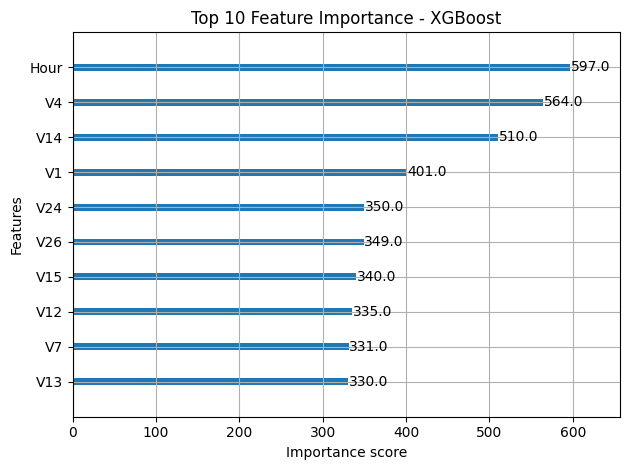

In [147]:
xgb.plot_importance(xgb_model.best_estimator_, max_num_features=10)
plt.title("Top 10 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
params = {
    'n_estimators': [100, 200, 300],
    
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2]
}

xgb_model = GridSearchCV(
    xgb.XGBClassifier(random_state=42),
    param_grid=params,
    scoring='f1',
    cv=5
)

xgb_model.fit(X_train_smote, y_train_smote)

y_pred_xgb = xgb_model.best_estimator_.predict(X_test)

print(f"Лучшие параметры: {xgb_model.best_params_}")

print("XGBoost - Recall:", recall_score(y_test, y_pred_xgb))
print("XGBoost - Precision:", precision_score(y_test, y_pred_xgb))
print("XGBoost - F1 Score:", f1_score(y_test, y_pred_xgb))
print("XGBoost - ROC AUC Score:", roc_auc_score(y_test, xgb_model.best_estimator_.predict_proba(X_test)[:, 1]))
print("XGBoost - Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

Лучшие параметры: {'learning_rate': 0.2, 'max_depth': 7, 'n_estimators': 300}
XGBoost - Recall: 0.8571428571428571
XGBoost - Precision: 0.7850467289719626
XGBoost - F1 Score: 0.8195121951219512
XGBoost - ROC AUC Score: 0.98054685436358
XGBoost - Confusion Matrix:
 [[56841    23]
 [   14    84]]


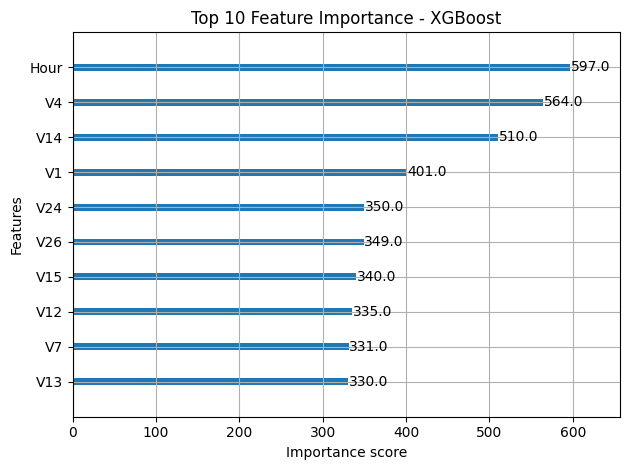

In [148]:
xgb.plot_importance(xgb_model.best_estimator_, max_num_features=10)
plt.title("Top 10 Feature Importance - XGBoost")
plt.tight_layout()
plt.show()

In [146]:
results = pd.DataFrame({
    'Model': [
        'LogReg baseline',
        'LogReg + SMOTE', 
        'LightGBM + class_weight',
        'LightGBM + SMOTE',
        'XGBoost + scale_pos_weight',
        'XGBoost + SMOTE'
    ],
    'Recall':    [0.653, 0.908, 0.837, 0.867, 0.827, 0.857],
    'Precision': [0.831, 0.054, 0.812, 0.491, 0.880, 0.785],
    'F1':        [0.731, 0.102, 0.824, 0.627, 0.853, 0.820],
    'AUC-ROC':   [0.954, 0.972, 0.964, 0.970, 0.975, 0.981]
})
print(results.sort_values('F1', ascending=False).to_string(index=False))

                     Model  Recall  Precision    F1  AUC-ROC
XGBoost + scale_pos_weight   0.827      0.880 0.853    0.975
   LightGBM + class_weight   0.837      0.812 0.824    0.964
           XGBoost + SMOTE   0.857      0.785 0.820    0.981
           LogReg baseline   0.653      0.831 0.731    0.954
          LightGBM + SMOTE   0.867      0.491 0.627    0.970
            LogReg + SMOTE   0.908      0.054 0.102    0.972
